In [ ]:
!rm -rf /content/*
from google.colab.patches import cv2_imshow
!git clone https://github.com/fiesc-junior-prado/arquivos_de_aula.git
dir_imagens = '/content/arquivos_de_aula/modulo2/arquivos/imagens/'

Cloning into 'arquivos_de_aula'...
remote: Enumerating objects: 12969, done.
remote: Counting objects: 100% (55/55), done.
remote: Compressing objects: 100% (35/35), done.
remote: Total 12969 (delta 16), reused 48 (delta 10), pack-reused 12914 (from 2)
Receiving objects: 100% (12969/12969), 193.16 MiB | 14.59 MiB/s, done.
Resolving deltas: 100% (762/762), done.
Updating files: 100% (11817/11817), done.


# Aula 1

In [ ]:
def newScala(img, escala):
  largura = img.shape[1]
  altura = img.shape[0]
  canais = img.shape[2]
  img_resize=cv2.resize(img,(int(largura*escala),int(altura*escala)))
  return img_resize

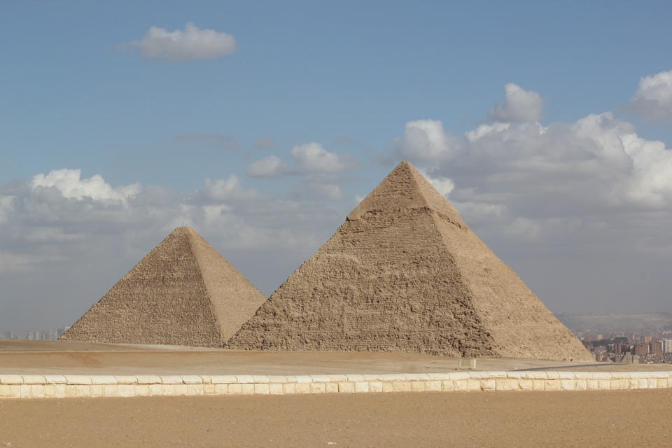

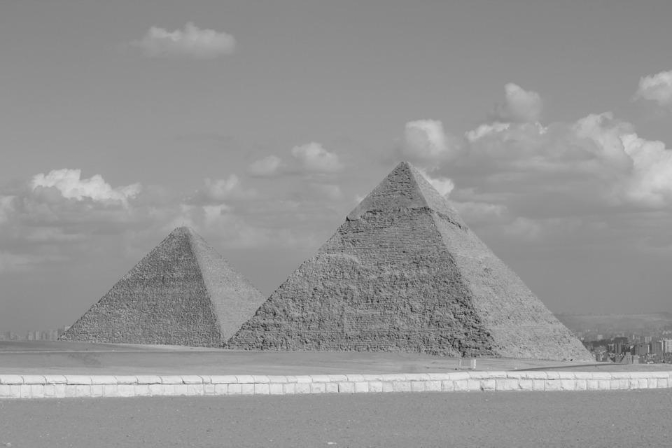

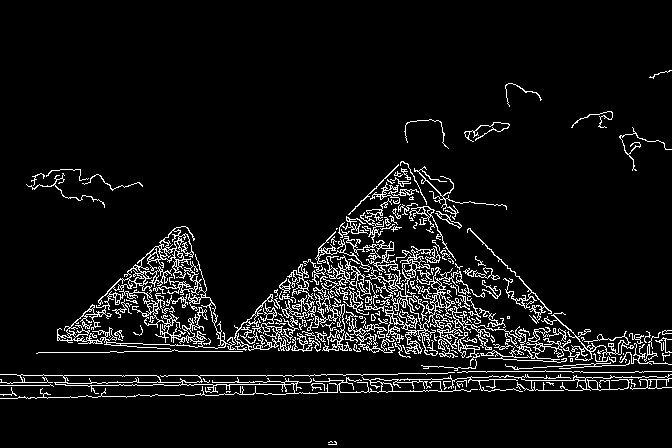

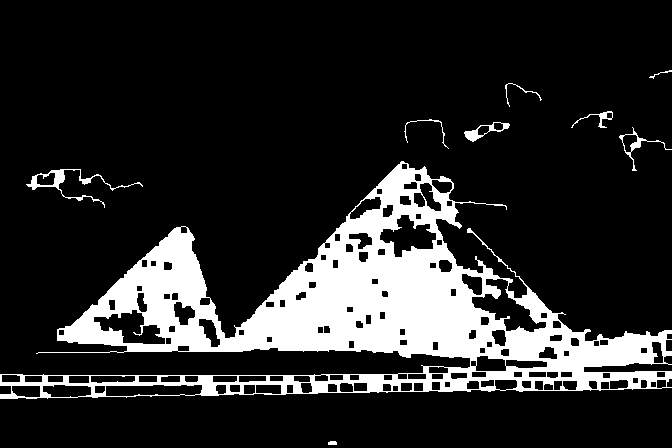

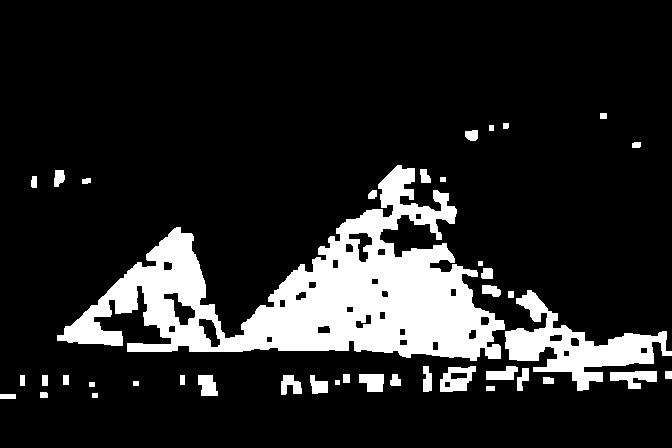

In [ ]:
import cv2
import numpy as np

img = cv2.imread(f'{dir_imagens}/piramide.jpg')


if img is not None:
  # resize da image
  img_resize=newScala(img, 0.7)
  # converter para cinza
  img_cinza = cv2.cvtColor(img_resize, cv2.COLOR_BGR2GRAY)
  # aplicar blur
  img_blur = cv2.GaussianBlur(img_cinza, (3,3), 0)
  #  canny
  img_canny = cv2.Canny(img_blur, 20, 100)

  kernel = np.ones((5,5), np.uint8)
  #alicar fechamento
  img_closing = cv2.morphologyEx(img_canny, cv2.MORPH_CLOSE, kernel)
  # aplicando abertura
  img_opening = cv2.morphologyEx(img_closing, cv2.MORPH_OPEN, kernel)

  # mostrar imagem
  cv2_imshow(img_resize)
  cv2_imshow(img_cinza)
  cv2_imshow(img_canny)
  cv2_imshow(img_closing)
  cv2_imshow(img_opening)

else:
  print('Erro ao carregar a imagem')


## SEPARAR OBJETOS DE UMA IMAGEM

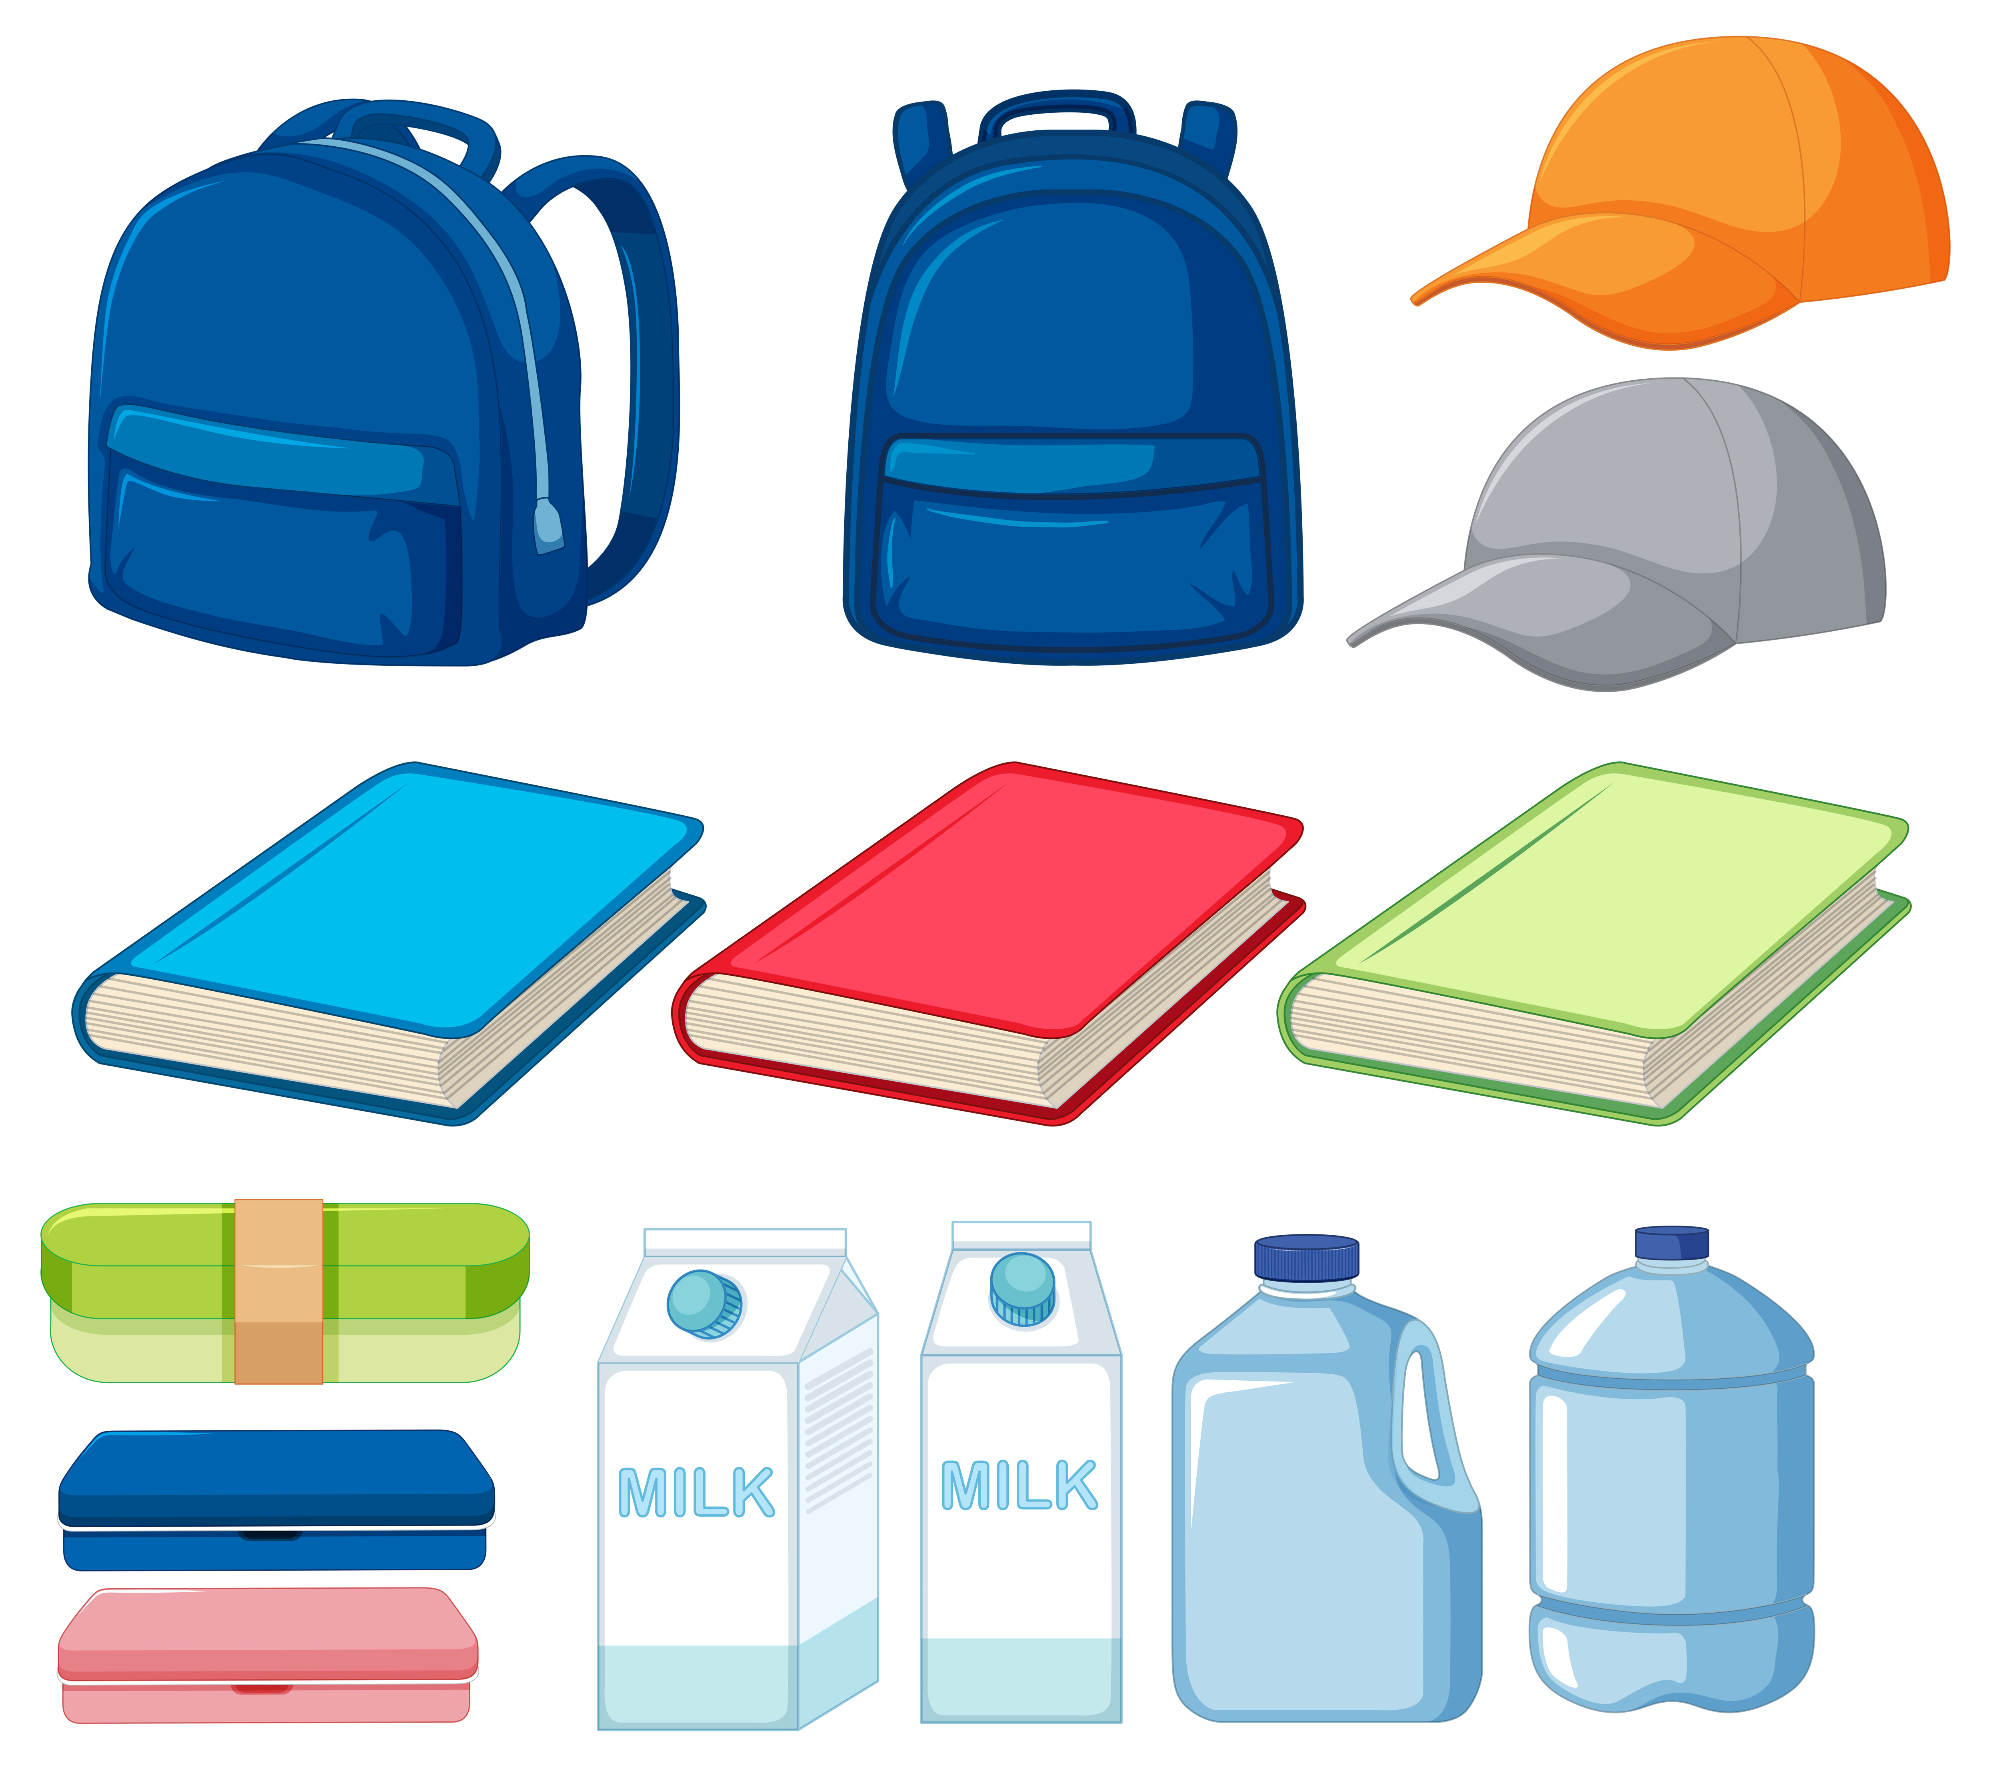

Foram encontrados 14 objetos


In [ ]:
import cv2
import numpy as np
import os

img = cv2.imread(f'{dir_imagens}/objetos.jpg')
if img is not None:
  # redimensinar
  img_resize = newScala(img, 0.4)
  # converter para cinza
  img_cinza = cv2.cvtColor(img_resize, cv2.COLOR_BGR2GRAY)
  # aplicar blur
  img_blur = cv2.GaussianBlur(img_cinza, (3,3), 0)
  # cv2_imshow(img_blur)
  # canny
  img_canny = cv2.Canny(img_blur, 30, 200)
  # cv2_imshow(img_canny)
  # fechamento
  kernel = np.ones((7,7), np.uint8)
  img_closing = cv2.morphologyEx(img_canny, cv2.MORPH_CLOSE, kernel)
  # cv2_imshow(img_closing)
  # encontrando os contornos
  contornos, _ = cv2.findContours(img_closing, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
  count = 0
  repository= "/content/objetos"
  os.makedirs(repository, exist_ok=True)

  for contorno in contornos:
    area = cv2.contourArea(contorno)
    if area > 1000:
      x,y,w,h = cv2.boundingRect(contorno)
      # cv2.rectangle(img_resize, (x,y), (x+w, y+h), (0,255,0), 2)
      count += 1
      objeto = img_resize[y:y+h, x:x+w]
      cv2.imwrite(f'{repository}/objeto{count}.jpg', objeto)

      # cv2.drawContours(img_resize, [contorno], -1, (0,255,0), 2)
  cv2_imshow(img_resize)
  print(f'Foram encontrados {count} objetos')
else:
  print('Erro ao carregar a imagem')

## Scanner

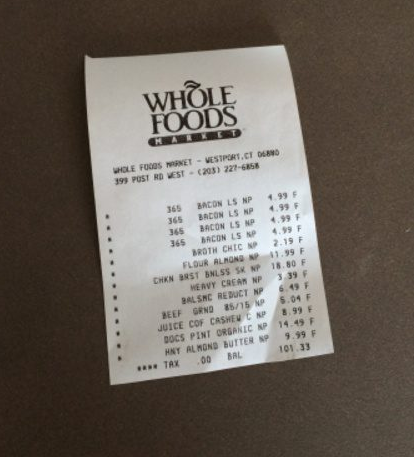

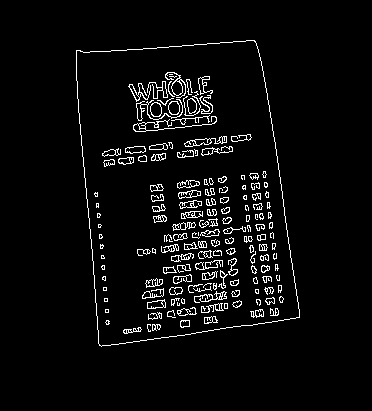

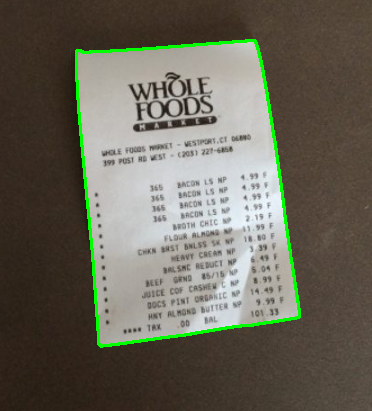

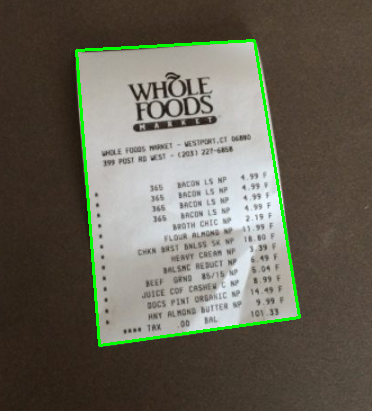

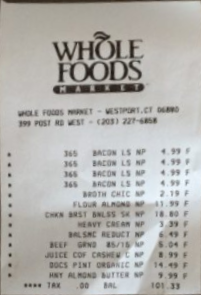

In [ ]:
import cv2

## função auxxiliar
def ordenar_pontos(pts):
    rect = np.zeros((4, 2), dtype="float32")

    s = pts.sum(axis=1)
    rect[0] = pts[np.argmin(s)]
    rect[2] = pts[np.argmax(s)]

    diff = np.diff(pts, axis=1)
    rect[1] = pts[np.argmin(diff)]
    rect[3] = pts[np.argmax(diff)]

    return rect

img= cv2.imread(f'{dir_imagens}/nota.png')

if img is not None:
  cv2_imshow(img)
  img_resize  = newScala(img, 0.9)
  # cv2_imshow(img_resize)

  copy = img_resize.copy()
  img_cinza = cv2.cvtColor(copy, cv2.COLOR_BGR2GRAY)
  # cv2_imshow(img_cinza)

  # blur
  img_blur = cv2.GaussianBlur(img_cinza, (3,3), 0)
  # bordas
  img_canny = cv2.Canny(img_blur, 75, 200)
  cv2_imshow(img_canny)
  # contornos
  contornos, _ = cv2.findContours(img_canny, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
  contornos = sorted(contornos, key=cv2.contourArea, reverse=True)
  # Nova imagem
  img_contorno = img_resize.copy()
  img_contorno_corrigido = img_resize.copy()

  cv2.drawContours(img_contorno, contornos, 0, (0,255,0), 2)
  cv2_imshow(img_contorno)

  # ajeitando contornos
  contorno_corrido = None
  for contorno in contornos:
    perimetro = cv2.arcLength(contorno, True)
    aproximacao = cv2.approxPolyDP(contorno, 0.02*perimetro, True)
    if len(aproximacao) == 4:
      contorno_corrido = aproximacao
      break
  if contorno_corrido is not None:
    cv2.drawContours(img_contorno_corrigido, [contorno_corrido], 0, (0,255,0), 2)
    cv2_imshow(img_contorno_corrigido)

  # Executa a transformação apenas se encontrou o documento
    if contorno_corrido is not None:
        # =====================================================================
        # PASSO 4: Transformação de Perspectiva
        # =====================================================================
        pontos = contorno_corrido.reshape(4, 2)
        rect = ordenar_pontos(pontos)
        (tl, tr, br, bl) = rect

        larguraA = np.sqrt(((br[0] - bl[0]) ** 2) + ((br[1] - bl[1]) ** 2))
        larguraB = np.sqrt(((tr[0] - tl[0]) ** 2) + ((tr[1] - tl[1]) ** 2))
        maxLargura = max(int(larguraA), int(larguraB))

        alturaA = np.sqrt(((tr[0] - br[0]) ** 2) + ((tr[1] - br[1]) ** 2))
        alturaB = np.sqrt(((tl[0] - bl[0]) ** 2) + ((tl[1] - bl[1]) ** 2))
        maxAltura = max(int(alturaA), int(alturaB))

        destino = np.array([
            [0, 0],
            [maxLargura - 1, 0],
            [maxLargura - 1, maxAltura - 1],
            [0, maxAltura - 1]], dtype="float32")

        matriz = cv2.getPerspectiveTransform(rect, destino)
        scan = cv2.warpPerspective(img_resize, matriz, (maxLargura, maxAltura))
        cv2_imshow(scan)
else:
  print('Erro ao carregar a imagem')

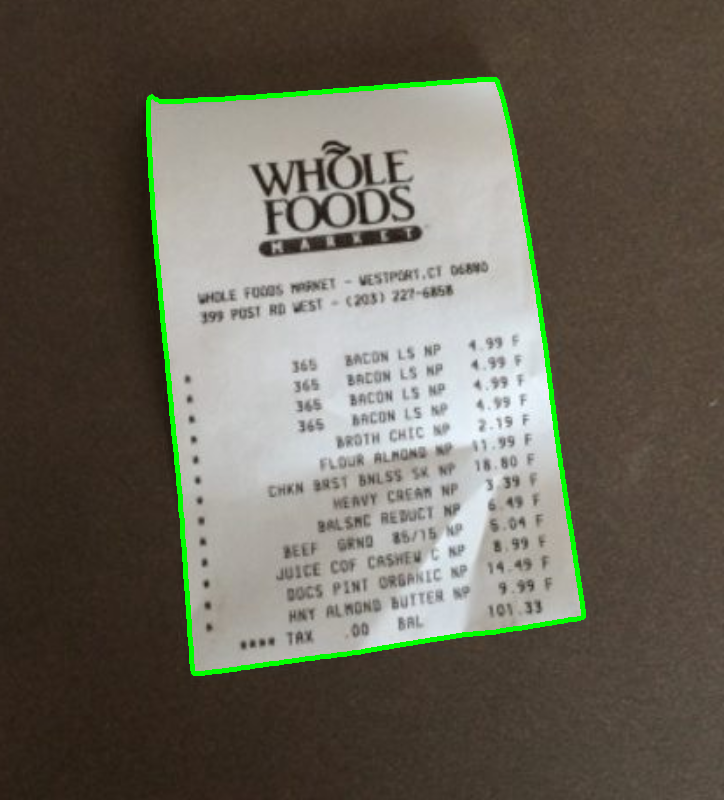

1. Imagem Original com Contorno Identificado:


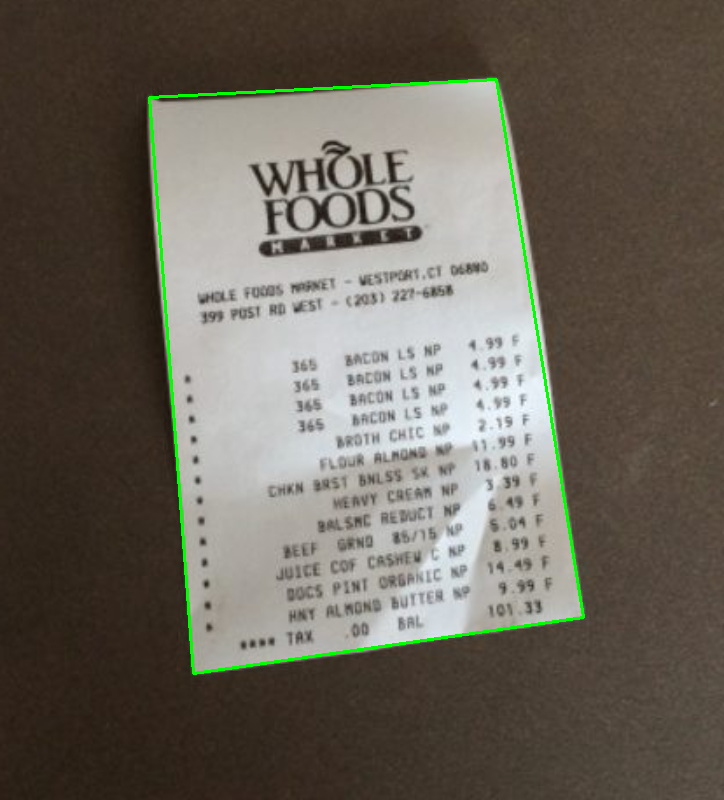


2. Documento com Perspectiva Corrigida:


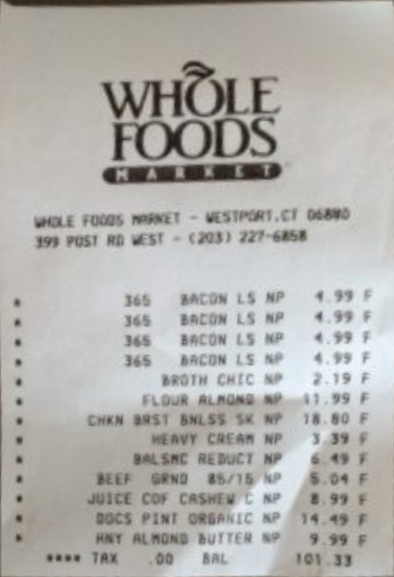


3. Efeito Scanner Final (Preto e Branco):


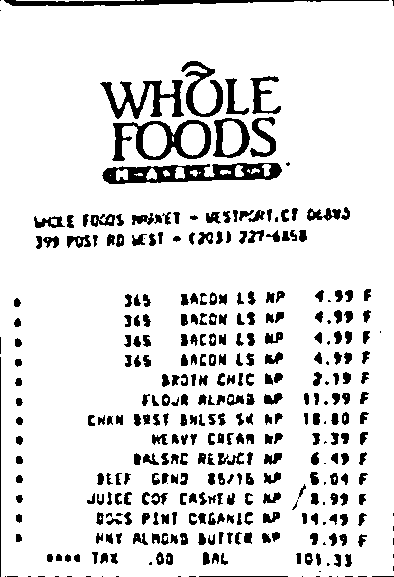

In [ ]:

# =====================================================================
# PASSO 1: Preparação da Imagem
# =====================================================================
# Lendo a imagem que já está no ambiente do Colab
imagem = cv2.imread(f'{dir_imagens}/nota.png')

# Verificação de segurança caso o nome da imagem esteja incorreto
if imagem is None:
    print("Erro: Imagem 'documento.jpg' não encontrada. Verifique na aba de arquivos (ícone de pasta à esquerda).")
else:
    # Redimensiona para acelerar o processamento
    proporcao = imagem.shape[0] / 800.0
    imagem_redimensionada = cv2.resize(imagem, (int(imagem.shape[1] / proporcao), 800))
    imagem_original = imagem_redimensionada.copy()

    # Escala de cinza e Blur
    cinza = cv2.cvtColor(imagem_redimensionada, cv2.COLOR_BGR2GRAY)
    desfoque = cv2.GaussianBlur(cinza, (5, 5), 0)

    # =====================================================================
    # PASSO 2 e 3: Bordas e Contorno
    # =====================================================================
    bordas = cv2.Canny(desfoque, 75, 200)
    contornos, _ = cv2.findContours(bordas, cv2.RETR_LIST, cv2.
    CHAIN_APPROX_SIMPLE)
    contornos = sorted(contornos, key=cv2.contourArea, reverse=True)[:5]
    newImage = imagem_redimensionada.copy()
    cv2.drawContours(newImage, contornos, 0, (0, 255, 0), 3)
    cv2_imshow(newImage)


    contorno_documento = None

    for c in contornos:
        perimetro = cv2.arcLength(c, True)
        aproximacao = cv2.approxPolyDP(c, 0.02 * perimetro, True)

        if len(aproximacao) == 4:
            contorno_documento = aproximacao
            break

    if contorno_documento is not None:
        cv2.drawContours(imagem_original, [contorno_documento], -1, (0, 255, 0), 2)
    else:
        print("Documento não encontrado. O código será interrompido.")

    # Executa a transformação apenas se encontrou o documento
    if contorno_documento is not None:
        # =====================================================================
        # PASSO 4: Transformação de Perspectiva
        # =====================================================================
        pontos = contorno_documento.reshape(4, 2)
        rect = ordenar_pontos(pontos)
        (tl, tr, br, bl) = rect

        larguraA = np.sqrt(((br[0] - bl[0]) ** 2) + ((br[1] - bl[1]) ** 2))
        larguraB = np.sqrt(((tr[0] - tl[0]) ** 2) + ((tr[1] - tl[1]) ** 2))
        maxLargura = max(int(larguraA), int(larguraB))

        alturaA = np.sqrt(((tr[0] - br[0]) ** 2) + ((tr[1] - br[1]) ** 2))
        alturaB = np.sqrt(((tl[0] - bl[0]) ** 2) + ((tl[1] - bl[1]) ** 2))
        maxAltura = max(int(alturaA), int(alturaB))

        destino = np.array([
            [0, 0],
            [maxLargura - 1, 0],
            [maxLargura - 1, maxAltura - 1],
            [0, maxAltura - 1]], dtype="float32")

        matriz = cv2.getPerspectiveTransform(rect, destino)
        scan = cv2.warpPerspective(imagem_redimensionada, matriz, (maxLargura, maxAltura))

        # =====================================================================
        # PASSO 5: Binarização
        # =====================================================================
        scan_cinza = cv2.cvtColor(scan, cv2.COLOR_BGR2GRAY)
        scan_efeito = cv2.adaptiveThreshold(scan_cinza, 255, cv2.ADAPTIVE_THRESH_GAUSSIAN_C,cv2.THRESH_BINARY, 21, 10)

        # =====================================================================
        # MOSTRAR RESULTADOS NO COLAB
        # =====================================================================
        print("1. Imagem Original com Contorno Identificado:")
        cv2_imshow(imagem_original)

        print("\n2. Documento com Perspectiva Corrigida:")
        cv2_imshow(scan)

        print("\n3. Efeito Scanner Final (Preto e Branco):")
        cv2_imshow(scan_efeito)